In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('experiments/early-boost.csv')

In [3]:
mean_importance = df['mean_importance']
std_importance = df['std_importance']

In [4]:
mean_importance = np.array([
    np.fromstring(row.strip("[]"), sep=" ")
    for row in df["mean_importance"]
])
mean_importance = mean_importance[0]
std_importance = np.array([
    np.fromstring(row.strip("[]"), sep=" ")
    for row in df["std_importance"]
])
std_importance = std_importance[0]

[0.09342609 0.08306701 0.08136611 0.08057943 0.07645681 0.07539172
 0.0698888  0.06746946 0.06361647 0.05576861 0.05555769 0.05392216
 0.05379125 0.04961512 0.04008325]


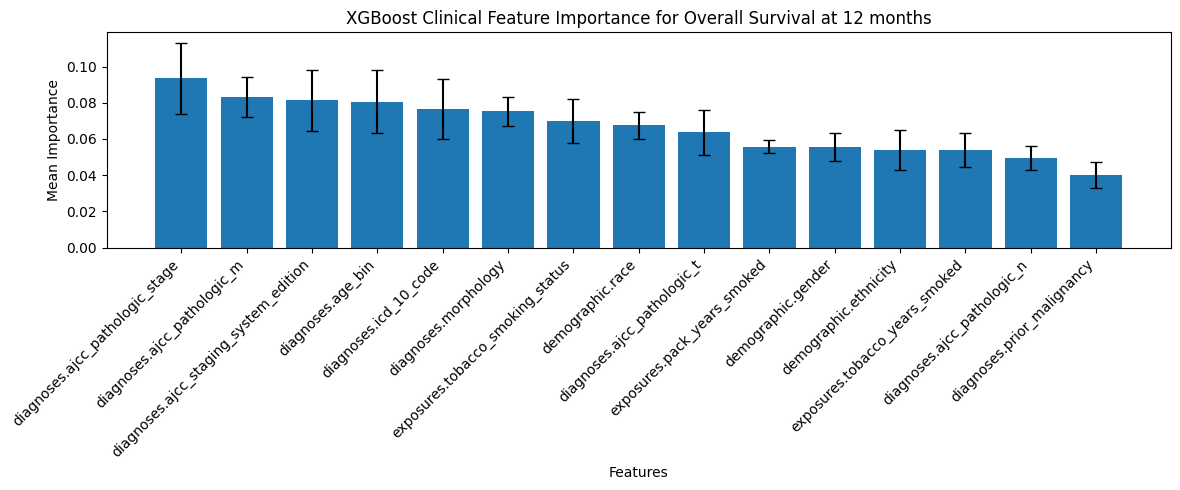

In [6]:
idx = np.argsort(mean_importance)[::-1]
labels = ['diagnoses.age_bin', 'demographic.ethnicity', 'demographic.gender', 'demographic.race', 'exposures.pack_years_smoked', 'exposures.tobacco_smoking_status', 'exposures.tobacco_years_smoked', 'diagnoses.ajcc_pathologic_m', 'diagnoses.ajcc_pathologic_n', 'diagnoses.ajcc_pathologic_stage', 'diagnoses.ajcc_pathologic_t', 'diagnoses.ajcc_staging_system_edition', 'diagnoses.icd_10_code', 'diagnoses.morphology', 'diagnoses.prior_malignancy']
sorted_importance = mean_importance[idx]
sorted_std = std_importance[idx]
sorted_labels = np.array(labels)[idx]
print(sorted_importance)

plt.figure(figsize=(12, 5))
plt.bar(
    range(len(sorted_importance)),
    sorted_importance,
    yerr=sorted_std,
    capsize=4
)

plt.xticks(
    range(len(sorted_labels)),
    sorted_labels,
    rotation=45,
    ha='right'
)

plt.xlabel("Features")
plt.ylabel("Mean Importance")
plt.title("XGBoost Clinical Feature Importance for Overall Survival at 12 months")
plt.tight_layout()
plt.show()